In [1]:
import training_pipeline
import datasets
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import graphing_pipeline
import test_error
import utils
import importlib
from mingpt.utils import set_seed
sns.set_context("paper", font_scale=1.5)
matplotlib.rcParams.update({'xtick.labelsize': 12})
matplotlib.rcParams.update({'ytick.labelsize': 12})
# device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
# training_pipeline.device = "cpu"
device = training_pipeline.device

conf = training_pipeline.get_default_config()
histories = []
datem = []
bigram_data = []
unigram_data = []
seeds = [0]
path = "blog"
def get_test_sets(config):
  bigram_dataset = datasets.doubly_stochastic('test', config.block_size+1, num_symbols = config.vocab_size,)
  unigram_dataset = datasets.unigram('test', config.block_size+1, num_symbols=config.vocab_size)
  
  return bigram_dataset, unigram_dataset

In [4]:
n = 2
from torch.profiler import profile, record_function, ProfilerActivity

# from datasets import ngrams
conf = training_pipeline.get_default_config()
histories, datem, bigram_data, unigram_data = [], [], [], []
# conf.model_type = f'one head (attention only, corrected rel pos)'
# conf.model_type = "transformer"
conf.model_type = 'Attention-Only Relative positions Transformer'
print(f"n={n}")
conf.vocab_size = 2
conf.n_head = n - 1
conf.n_embd = 16 * conf.n_head #* 3
conf.n_layer = 2
conf.max_iters = 2000
conf.n = n
conf.block_size = 100
conf.batch_size = 64
conf.num_workers = 6
# conf.learning_rate = 4e-3
conf.learning_rate = 5e-4

n=2


In [9]:
conf.dataset = datasets.ngrams('train', n, conf.block_size+1, conf.vocab_size, last_token_only=False)
name = f"{conf.vocab_size}transformer_symb_{n}gram"
test_dataset = datasets.ngrams('test', n, conf.block_size+1, conf.vocab_size, size = int(1e7))

In [31]:
if conf.vocab_size < 4 and conf.n == 2:
    bigram_dataset, unigram_dataset = get_test_sets(conf)

In [29]:
for seed in seeds:
    conf.seed = seed
    set_seed(seed)
    model_history, train_loss = training_pipeline.train(conf) 
    histories.append(model_history)

config seed: 0
number of parameters: 5440
running on device cuda:0
iter_dt 0.00 ms; iter 0: train loss 0.719784
iter_dt 8.14 ms; iter 400: train loss 0.552065
iter_dt 10.50 ms; iter 800: train loss 0.568428
iter_dt 10.01 ms; iter 1200: train loss 0.565426
iter_dt 11.53 ms; iter 1600: train loss 0.505751


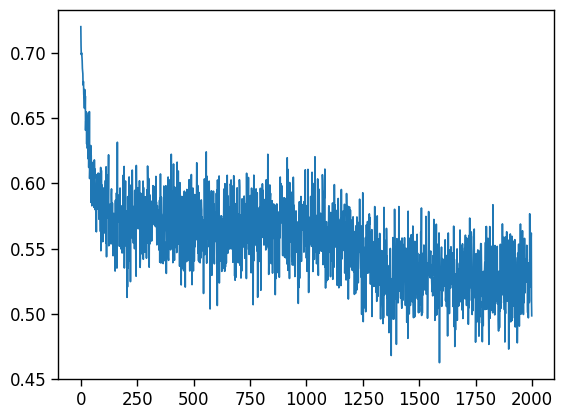

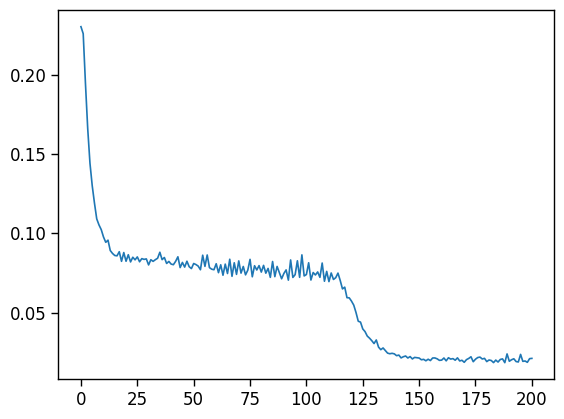

In [32]:
plt.plot(train_loss)
plt.show()
for model_history in histories:
    data = test_error.test_last_token(model_history, test_dataset, device)
    datem.append(data)
    
    plt.plot(datem[-1][0])
    if conf.vocab_size < 4 and conf.n == 2:
        data = test_error.test_last_token(model_history, bigram_dataset, device)
        bigram_data.append(data)
        data = test_error.test_last_token(model_history, unigram_dataset, device)
        unigram_data.append(data)

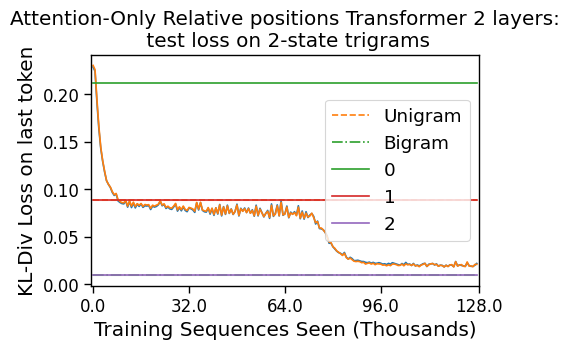

In [33]:
axes = graphing_pipeline.test_loss(datem, conf) 
plt.legend()
# plt.savefig(f"{path}/{name}_test_loss.pdf", format='pdf', bbox_inches='tight')
for lab, i in enumerate(datem[-1][1]):
    plt.plot((i,)*len(datem[-1][0]), label = f"{lab}")
plt.legend()
plt.show()

## Visualize

In [10]:
print(conf.dataset.__dict__)

{'length': 101, 'num_symbols': 2, 'split': 'train', 'offline': False, 'size': 1000, 'last_token_only': False, 'device': 'cpu', 'n': 1, 'transition_matrix_gen': <bound method Distribution.sample of Dirichlet(concentration: torch.Size([2, 2]))>, 'powers': tensor([1]), 'conv': tensor([1])}


In [11]:
conf.dataset.transition_matrix_gen # a function

<bound method Distribution.sample of Dirichlet(concentration: torch.Size([2, 2]))>

In [13]:
x, y = conf.dataset[0]

In [14]:
len(x)

101

In [15]:
len(y)

101

In [22]:
import torch
import datasets
from utils import stationary_distribution

# 1. 設定參數
config = {
    'split': 'test',     # 關鍵：一定要設為 'test'，才會回傳轉移矩陣
    'n': 2,              # N-gram 的 N (2 代表 Bigram)
    'length': 101,       # 序列長度
    'num_symbols': 3,    # 詞彙表大小 (設小一點比較好觀察，例如 3 或 5)
    'device': 'cpu'
}

# 2. 初始化 Dataset
# 注意：這裡長度參數通常是 block_size + 1
dataset = datasets.ngrams(
    split=config['split'],
    n=config['n'],
    length=config['length'],
    num_symbols=config['num_symbols'],
    device=config['device']
)

# 3. 取得一筆資料
# __getitem__ 回傳格式：x, y
# 在 split='test' 時，y 是一個 tuple: (transition_matrix, target_sequence)
idx = 0
x, y_tuple = dataset[idx] 
transition_matrix, target_seq = y_tuple

# 4. 計算穩態分佈 (Stationary Distribution)
# Dataset 類別裡雖然有計算穩態，但沒有直接 return 出來。
# 我們可以使用 dataset 實例的方法，或是 utils 的函式來算。
stationary = dataset.stationary_distribution(transition_matrix)

# --- 顯示結果 ---
print(f"=== Sample {idx} ===")
print("\n1. Transition Matrix (轉移矩陣):")
print(f"Shape: {transition_matrix.shape}") # (S, S) 或 (S^(N-1), S)
print(transition_matrix)

print("\n2. Stationary Distribution (穩態分佈):")
print(f"Shape: {stationary.shape}")
print(stationary)

print("\n3. Generated Sequence Snippet (生成序列前10個字):")
print(x[:10])

# 驗證：穩態分佈 * 轉移矩陣 應該要等於 穩態分佈 (對於 Bigram)
if config['n'] == 2:
    check = torch.matmul(stationary, transition_matrix)
    print("\n4. Consistency Check (Stationary * P == Stationary?):")
    print(torch.allclose(check, stationary, atol=1e-4))

=== Sample 0 ===

1. Transition Matrix (轉移矩陣):
Shape: torch.Size([3, 3])
tensor([[0.5195, 0.0184, 0.4621],
        [0.0533, 0.8009, 0.1458],
        [0.3876, 0.4558, 0.1566]])

2. Stationary Distribution (穩態分佈):
Shape: torch.Size([3])
tensor([0.2404, 0.5354, 0.2243])

3. Generated Sequence Snippet (生成序列前10個字):
tensor([0, 0, 2, 1, 0, 0, 2, 0, 2, 2])

4. Consistency Check (Stationary * P == Stationary?):
True


In [27]:
import torch
import datasets

# 1. 設定參數 (以 n=3 Trigram 為例)
config = {
    'split': 'test',
    'n': 3,              # Trigram (看前兩個字預測下一個)
    'length': 20,
    'num_symbols': 3,    # 設小一點 (3) 方便肉眼觀察
    'device': 'cpu'
}

# 2. 初始化 Dataset
dataset = datasets.ngrams(
    split=config['split'],
    n=config['n'],
    length=config['length'],
    num_symbols=config['num_symbols'],
    device=config['device']
)

# 3. 取得資料與轉移矩陣
# 使用 [0, 0] 避開 squeeze 的 Bug
batch_data = dataset.__getitems__([0, 0]) 
transition_matrix = batch_data[0][1][0] # 取出第一筆資料的轉移矩陣

# 4. 計算 Stationary Distribution
# 關鍵：datasets.py 的 stationary_distribution 函式預期輸入是 3D (Batch, State, Symbol)
# 但我們拿到的矩陣是 2D (State, Symbol)，所以要用 unsqueeze(0) 加一個 Batch 維度
transition_matrix_3d = transition_matrix.unsqueeze(0) 

# 呼叫 dataset 內的方法計算
stationary_distribution = dataset.stationary_distribution(transition_matrix_3d)

# 算完後把 Batch 維度拿掉，變回 1D 向量
stationary_distribution = stationary_distribution.squeeze(0)

# --- 顯示結果 ---
print(f"=== 設定: N={config['n']}, Symbols={config['num_symbols']} ===\n")

print(f"1. Transition Matrix 形狀: {transition_matrix.shape}")
print(f"   (解釋: {config['num_symbols']**(config['n']-1)} 個歷史狀態 -> {config['num_symbols']} 個下一個字的機率)")
# print(transition_matrix) # 想看矩陣細節可以 uncomment

print(f"\n2. Stationary Distribution 形狀: {stationary_distribution.shape}")
print(f"   (解釋: 對應 {config['num_symbols']**(config['n']-1)} 個歷史狀態的長期發生機率)")
print(stationary_distribution)

print("\n3. 總和檢查 (應該要接近 1):")
print(stationary_distribution.sum().item())

=== 設定: N=3, Symbols=3 ===

1. Transition Matrix 形狀: torch.Size([9, 3])
   (解釋: 9 個歷史狀態 -> 3 個下一個字的機率)

2. Stationary Distribution 形狀: torch.Size([9])
   (解釋: 對應 9 個歷史狀態的長期發生機率)
tensor([0.1139, 0.0846, 0.1168, 0.1488, 0.2065, 0.0722, 0.0527, 0.1364, 0.0682])

3. 總和檢查 (應該要接近 1):
0.9999999403953552


In [28]:
# 假設 stationary 是那 9 維的向量 (Shape: 9)
# 它的意義對應到： (0,0), (0,1), (0,2), (1,0), (1,1)...

num_symbols = 3
n = 3

# 1. 把它 reshape 成 (前一個字, 當前字)
# Shape 變成 (3, 3)
stationary_matrix = stationary_distribution.view(num_symbols, num_symbols)

# 2. 對「前一個字」做加總 (Marginalize)
# 這樣就剩下「當前字」的機率了
symbol_stationary = stationary_matrix.sum(dim=0)

print(f"原本的狀態分佈 (History): {stationary_distribution.shape}") # Shape: [9]
print(f"單字的分佈 (Symbol):    {symbol_stationary.shape}")    # Shape: [3]
print("單字分佈內容:", symbol_stationary)

原本的狀態分佈 (History): torch.Size([9])
單字的分佈 (Symbol):    torch.Size([3])
單字分佈內容: tensor([0.3153, 0.4275, 0.2573])
